<a href="https://colab.research.google.com/github/sachindra-bb/Business-Case-Walmart---Confidence-Interval-and-CLT/blob/main/Business_Case_Walmart_Confidence_Interval_and_CLT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
# Load the dataset from the provided URL
url = "https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/293/original/walmart_data.csv?1641285094"
walmart_data = pd.read_csv(url)
# Observing the shape of the data and the first few rows
shape = walmart_data.shape
print("Shape of the data:")
print(shape)
print()
data_types = walmart_data.dtypes
print("Data types before conversion:")
print(data_types)
print()
head = walmart_data.head()
print("First few rows of the data:")
print(head)
print()


Shape of the data:
(550068, 10)

Data types before conversion:
User_ID                        int64
Product_ID                    object
Gender                        object
Age                           object
Occupation                     int64
City_Category                 object
Stay_In_Current_City_Years    object
Marital_Status                 int64
Product_Category               int64
Purchase                       int64
dtype: object

First few rows of the data:
   User_ID Product_ID Gender   Age  Occupation City_Category  \
0  1000001  P00069042      F  0-17          10             A   
1  1000001  P00248942      F  0-17          10             A   
2  1000001  P00087842      F  0-17          10             A   
3  1000001  P00085442      F  0-17          10             A   
4  1000002  P00285442      M   55+          16             C   

  Stay_In_Current_City_Years  Marital_Status  Product_Category  Purchase  
0                          2               0                 3  

In [4]:
# Converting specific columns to 'category' data type
columns_to_convert = ['Occupation', 'Marital_Status', 'Product_Category']
for col in columns_to_convert:
  if col in walmart_data.columns:
    walmart_data[col] = walmart_data[col].astype('category')
    print(f"Converted column '{col}' to category.")
  print()
# Updated data types after conversion
updated_data_types = walmart_data.dtypes
print("Data types after conversion:")
print(updated_data_types)
print()

Converted column 'Occupation' to category.

Converted column 'Marital_Status' to category.

Converted column 'Product_Category' to category.

Data types after conversion:
User_ID                          int64
Product_ID                      object
Gender                          object
Age                             object
Occupation                    category
City_Category                   object
Stay_In_Current_City_Years      object
Marital_Status                category
Product_Category              category
Purchase                         int64
dtype: object



In [7]:
# Unique value counts and unique attributes
value_counts = {col: walmart_data[col].value_counts() for col in walmart_data.select_dtypes(include='category').columns}
unique_attributes = {col: walmart_data[col].nunique() for col in walmart_data.columns}
print("Unique value counts for categorical columns:")
for col, counts in value_counts.items():
  print(f"{col}:\n{counts}\n")
  print()
print("Number of unique attributes per column:")
print(unique_attributes)

Unique value counts for categorical columns:
Occupation:
Occupation
4     72308
0     69638
7     59133
1     47426
17    40043
20    33562
12    31179
14    27309
2     26588
16    25371
6     20355
3     17650
10    12930
5     12177
15    12165
11    11586
19     8461
13     7728
18     6622
9      6291
8      1546
Name: count, dtype: int64


Marital_Status:
Marital_Status
0    324731
1    225337
Name: count, dtype: int64


Product_Category:
Product_Category
5     150933
1     140378
8     113925
11     24287
2      23864
6      20466
3      20213
4      11753
16      9828
15      6290
13      5549
10      5125
12      3947
7       3721
18      3125
20      2550
19      1603
14      1523
17       578
9        410
Name: count, dtype: int64


Number of unique attributes per column:
{'User_ID': 5891, 'Product_ID': 3631, 'Gender': 2, 'Age': 7, 'Occupation': 21, 'City_Category': 3, 'Stay_In_Current_City_Years': 5, 'Marital_Status': 2, 'Product_Category': 20, 'Purchase': 18105}


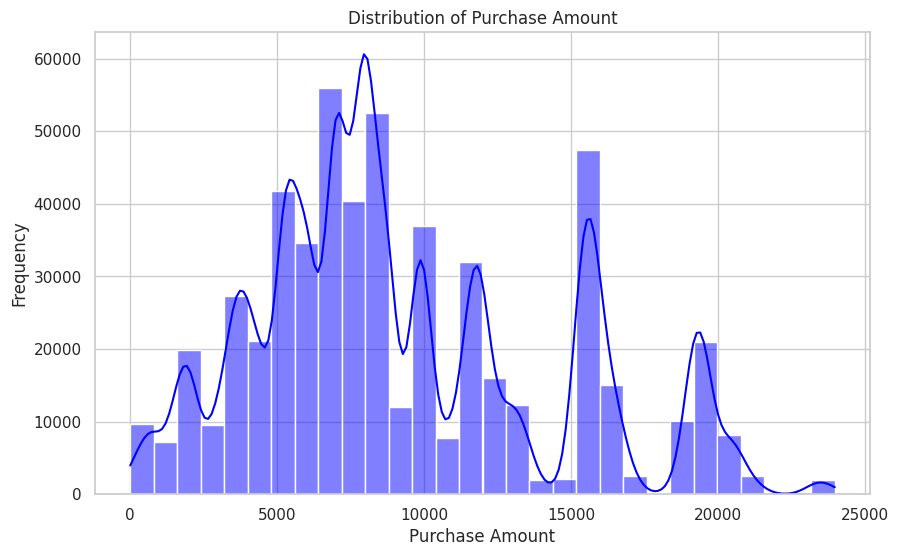

<ipython-input-8-1769a03e4f03>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=walmart_data[var], palette="viridis")


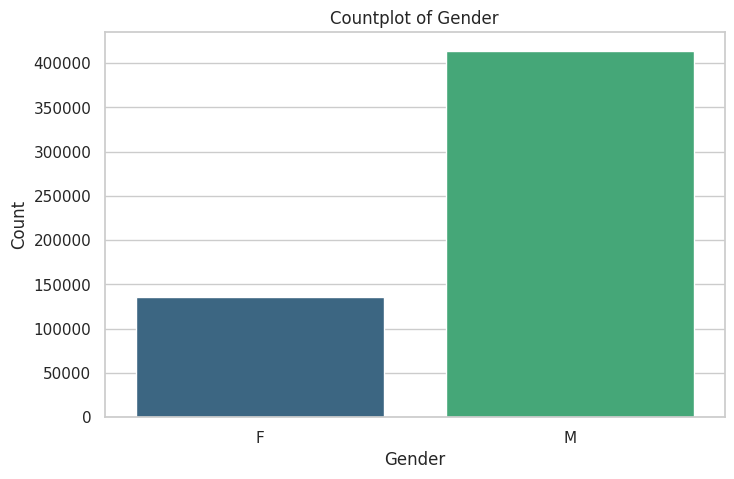

<ipython-input-8-1769a03e4f03>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=walmart_data[var], palette="viridis")


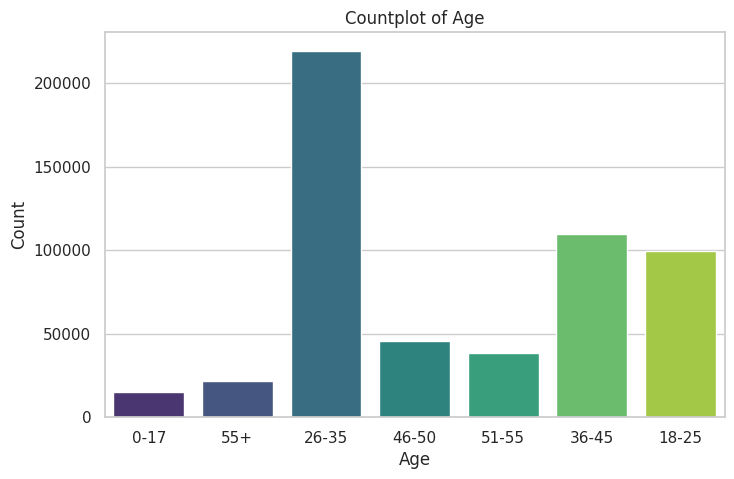

<ipython-input-8-1769a03e4f03>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=walmart_data[var], palette="viridis")


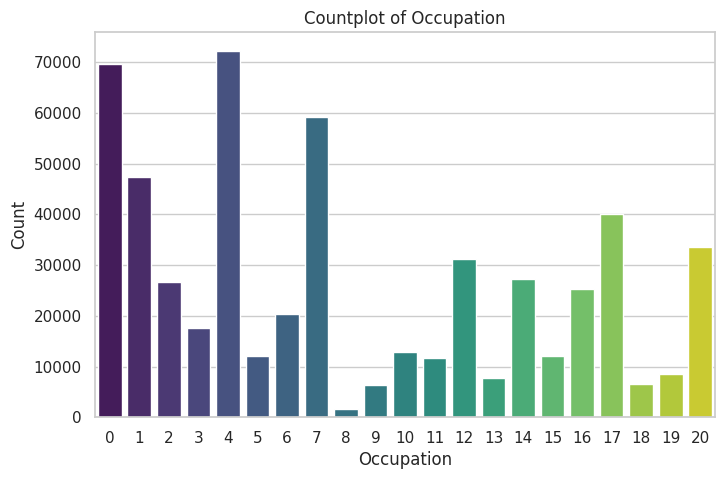

<ipython-input-8-1769a03e4f03>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=walmart_data[var], palette="viridis")


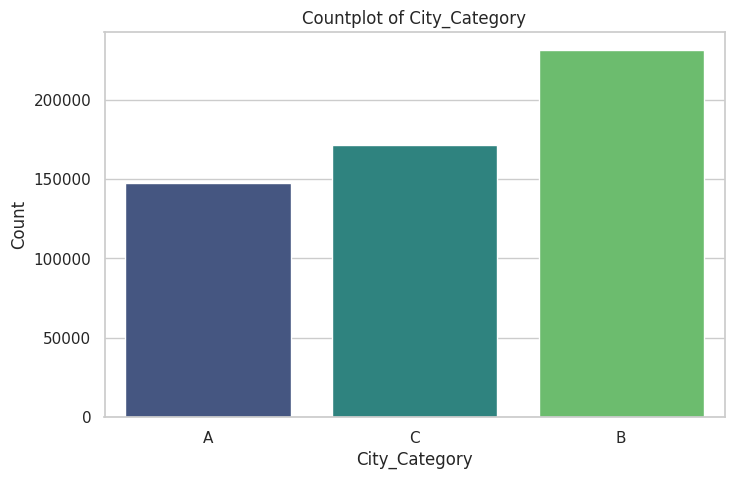

<ipython-input-8-1769a03e4f03>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=walmart_data[var], palette="viridis")


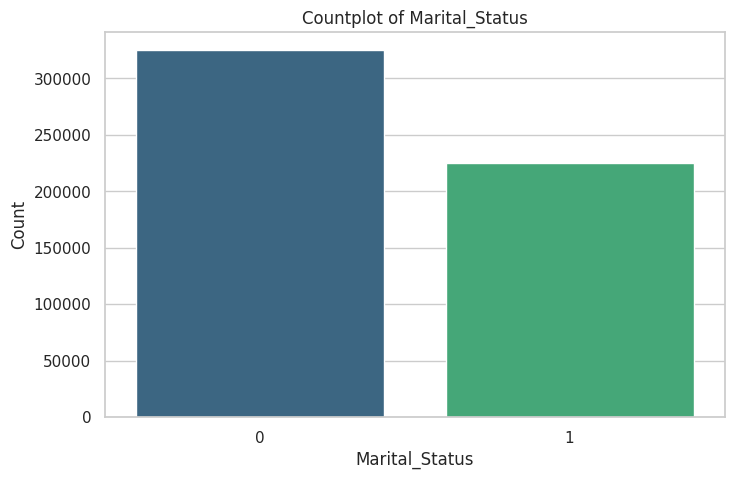

In [8]:
#Visual Analysis - Univariate & Bivariate
# For continuous variable(s): Distplot, countplot, histogram for univariate analysis
# For categorical variable(s): Boxplot
import seaborn as sns
import matplotlib.pyplot as plt
# Set a consistent visual style
sns.set(style="whitegrid")
# Univariate Analysis
# Continuous variables: 'Purchase'
plt.figure(figsize=(10, 6))
sns.histplot(walmart_data['Purchase'], kde=True, bins=30, color='blue')
plt.title("Distribution of Purchase Amount")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()
# Categorical variables: Countplots for 'Gender', 'Age', 'Occupation', 'City_Category', 'Marital_Status'
categorical_vars = ['Gender', 'Age', 'Occupation', 'City_Category', 'Marital_Status']
for var in categorical_vars:
  plt.figure(figsize=(8, 5))
  sns.countplot(x=walmart_data[var], palette="viridis")
  plt.title(f"Countplot of {var}")
  plt.xlabel(var)
  plt.ylabel("Count")
  plt.show()


<ipython-input-10-5babd3a91b78>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=walmart_data[cat_var], y=walmart_data['Purchase'], palette="Set2")


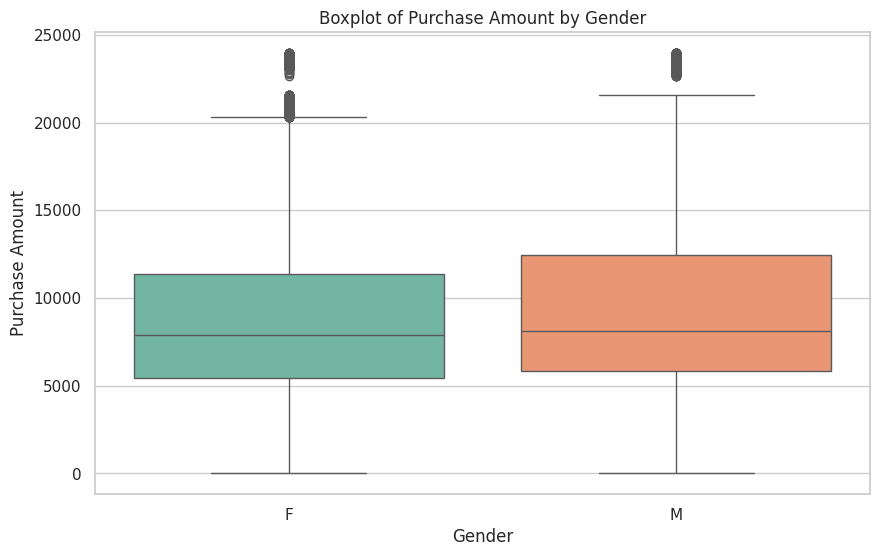

<ipython-input-10-5babd3a91b78>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=walmart_data[cat_var], y=walmart_data['Purchase'], palette="Set2")


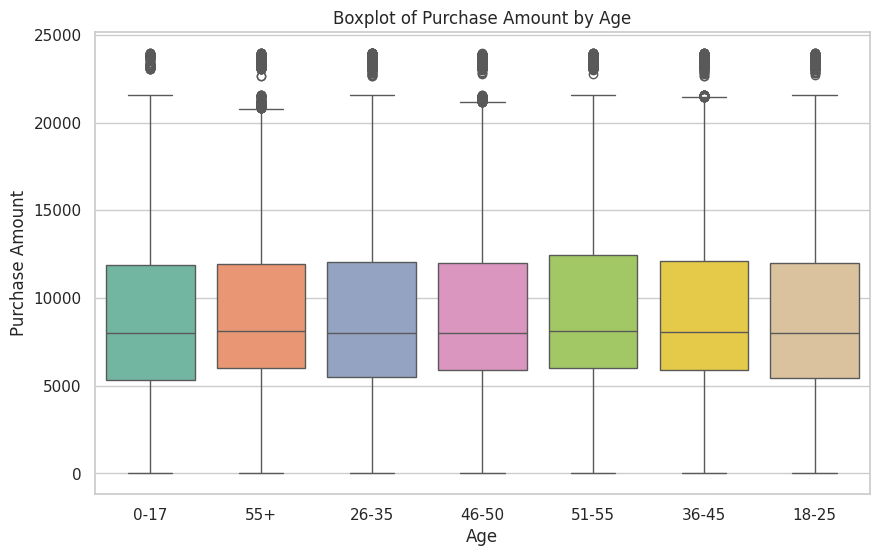

<ipython-input-10-5babd3a91b78>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=walmart_data[cat_var], y=walmart_data['Purchase'], palette="Set2")


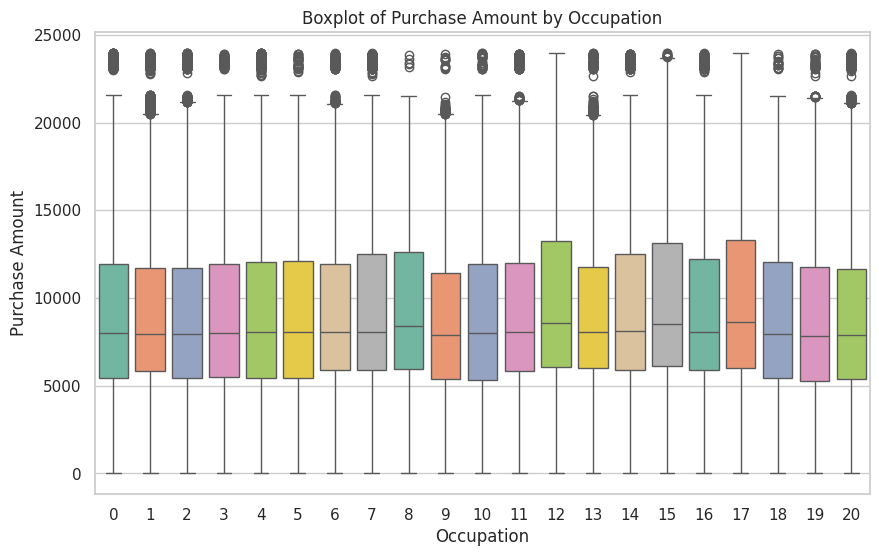

<ipython-input-10-5babd3a91b78>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=walmart_data[cat_var], y=walmart_data['Purchase'], palette="Set2")


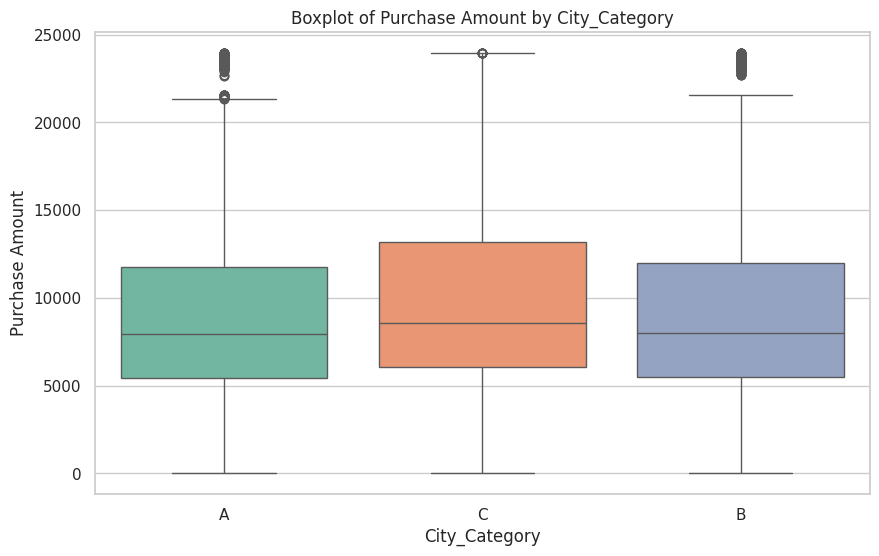

<ipython-input-10-5babd3a91b78>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=walmart_data[cat_var], y=walmart_data['Purchase'], palette="Set2")


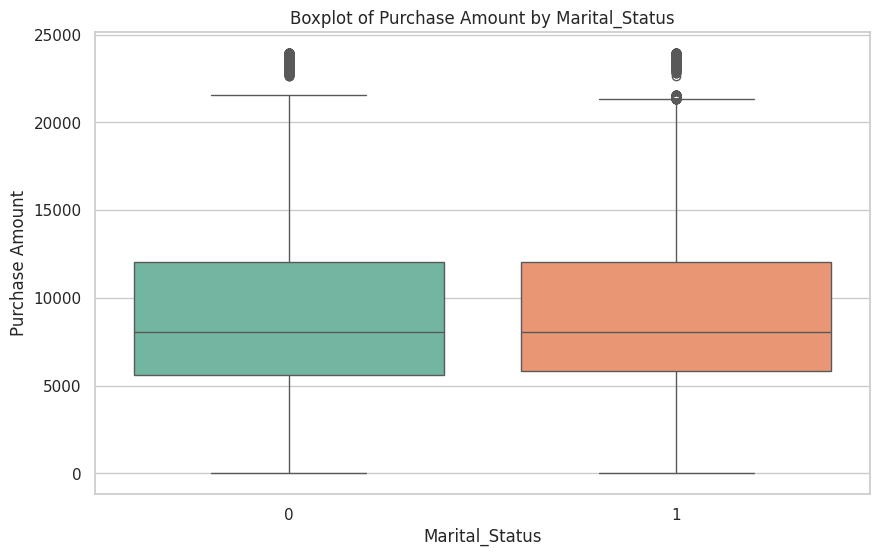

In [10]:
# Bivariate Analysis
# Boxplots for categorical vs continuous variables
for cat_var in categorical_vars:
  plt.figure(figsize=(10, 6))
  sns.boxplot(x=walmart_data[cat_var], y=walmart_data['Purchase'], palette="Set2")
  plt.title(f"Boxplot of Purchase Amount by {cat_var}")
  plt.xlabel(cat_var)
  plt.ylabel("Purchase Amount")
  plt.show()

In [11]:
# Missing value detection
missing_values = walmart_data.isnull().sum()
missing_percentage = (missing_values / len(walmart_data)) * 100
# Display missing value counts and percentages
missing_info = pd.DataFrame({
"Missing Count": missing_values,
"Missing Percentage (%)": missing_percentage
})
print("Missing Values in the Dataset:")
print(missing_info)

Missing Values in the Dataset:
                            Missing Count  Missing Percentage (%)
User_ID                                 0                     0.0
Product_ID                              0                     0.0
Gender                                  0                     0.0
Age                                     0                     0.0
Occupation                              0                     0.0
City_Category                           0                     0.0
Stay_In_Current_City_Years              0                     0.0
Marital_Status                          0                     0.0
Product_Category                        0                     0.0
Purchase                                0                     0.0


Outliers detected in Purchase:
Lower Bound: -3523.5, Upper Bound: 21400.5
Number of Outliers: 2677



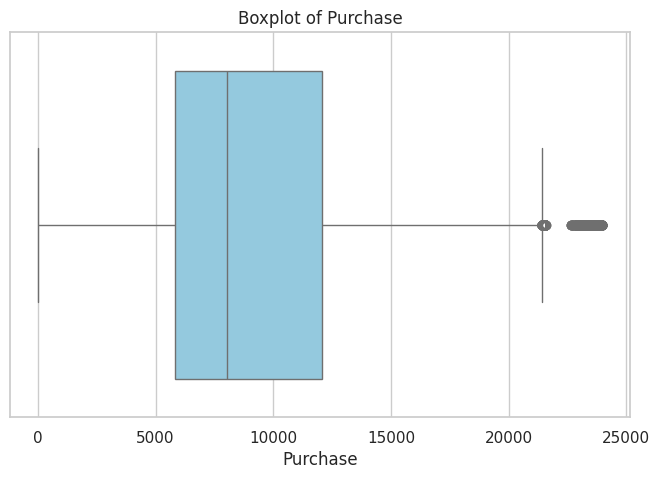

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
# Detecting outliers using IQR for the column 'Purchase'
col = 'Purchase'
Q1 = walmart_data[col].quantile(0.25)
Q3 = walmart_data[col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = walmart_data[(walmart_data[col] < lower_bound) | (walmart_data[col] > upper_bound)]
print(f"Outliers detected in {col}:")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
print(f"Number of Outliers: {len(outliers)}")
print()
# Visualizing outliers with a boxplot for 'Purchase'
plt.figure(figsize=(8, 5))
sns.boxplot(x=walmart_data[col], color='skyblue')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)
plt.show()

In [13]:
# Group by Gender and calculate the average purchase amount
gender_spending = walmart_data.groupby('Gender')['Purchase'].mean()
print("Average Spending by Gender:")
print(gender_spending)
# Conclusion based on average spending
if gender_spending['F'] > gender_spending['M']:
  print("\nOn average, women spend more money per transaction than men.")
elif gender_spending['F'] < gender_spending['M']:
  print("\nOn average, men spend more money per transaction than women.")
else:
  print("\nOn average, men and women spend the same amount per transaction.")

Average Spending by Gender:
Gender
F    8734.565765
M    9437.526040
Name: Purchase, dtype: float64

On average, men spend more money per transaction than women.


95% Confidence Interval for Male Spending: (9422.019162420047, 9453.032918524483)
95% Confidence Interval for Female Spending: (8709.211081242413, 8759.920449068539)


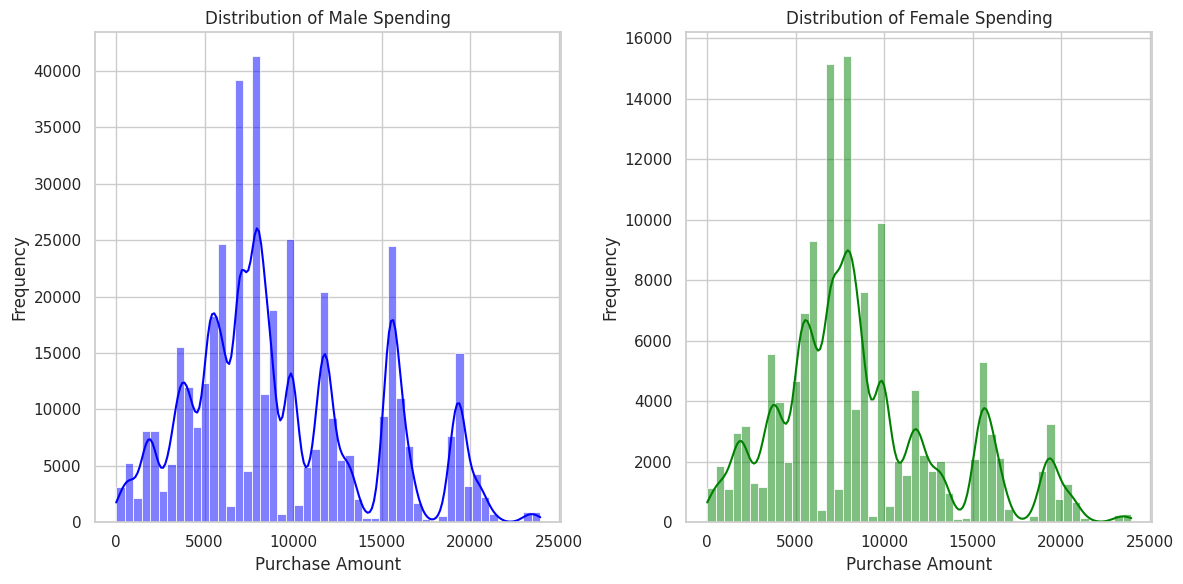

In [15]:
import numpy as np
# Grouping purchase data by Gender
male_purchase = walmart_data[walmart_data['Gender'] == 'M']['Purchase']
female_purchase = walmart_data[walmart_data['Gender'] == 'F']['Purchase']
# Calculate the mean and standard deviation for both genders
male_mean = male_purchase.mean()
female_mean = female_purchase.mean()
male_std = male_purchase.std()
female_std = female_purchase.std()
# Sample size
male_n = len(male_purchase)
female_n = len(female_purchase)
# 95% Confidence Interval calculation
z_value = 1.96 # For 95% confidence level
# Male Confidence Interval
male_margin_of_error = z_value * (male_std / np.sqrt(male_n))
male_ci_lower = male_mean - male_margin_of_error
male_ci_upper = male_mean + male_margin_of_error
# Female Confidence Interval
female_margin_of_error = z_value * (female_std / np.sqrt(female_n))
female_ci_lower = female_mean - female_margin_of_error
female_ci_upper = female_mean + female_margin_of_error
# Print Confidence Intervals
print(f"95% Confidence Interval for Male Spending: ({male_ci_lower}, {male_ci_upper})")
print(f"95% Confidence Interval for Female Spending: ({female_ci_lower}, {female_ci_upper})")
# Plotting Distribution (Histograms + KDE)
plt.figure(figsize=(12, 6))
# Male Distribution Plot
plt.subplot(1, 2, 1)
sns.histplot(male_purchase, kde=True, color='blue', bins=50)
plt.title("Distribution of Male Spending")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
# Female Distribution Plot
plt.subplot(1, 2, 2)
sns.histplot(female_purchase, kde=True, color='green', bins=50)
plt.title("Distribution of Female Spending")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [16]:
# Check for overlap in confidence intervals
if male_ci_upper >= female_ci_lower and female_ci_upper >= male_ci_lower:
  print("\nThe confidence intervals for male and female spending overlap.")
else:
  print("\nThe confidence intervals for male and female spending do not overlap.")
# Implication for Walmart
if male_ci_upper >= female_ci_lower and female_ci_upper >= male_ci_lower:
  print("\nSince the confidence intervals overlap, Walmart may not be able to distinctly differentiate spending patterns between male and female customers.")
  print("Walmart could focus on other factors (like product categories or shopping behavior) to segment customers more effectively.")
else:
  print("\nSince the confidence intervals do not overlap, Walmart can confidently conclude that male and female customers have distinct spending patterns.")
  print("Walmart can target promotions or tailor marketing strategies based on gender-specific preferences.")


The confidence intervals for male and female spending do not overlap.

Since the confidence intervals do not overlap, Walmart can confidently conclude that male and female customers have distinct spending patterns.
Walmart can target promotions or tailor marketing strategies based on gender-specific preferences.


95% Confidence Interval for Married Spending: (9240.460046422771, 9281.889101741976)
95% Confidence Interval for Unmarried Spending: (9248.61610045097, 9283.199137392043)


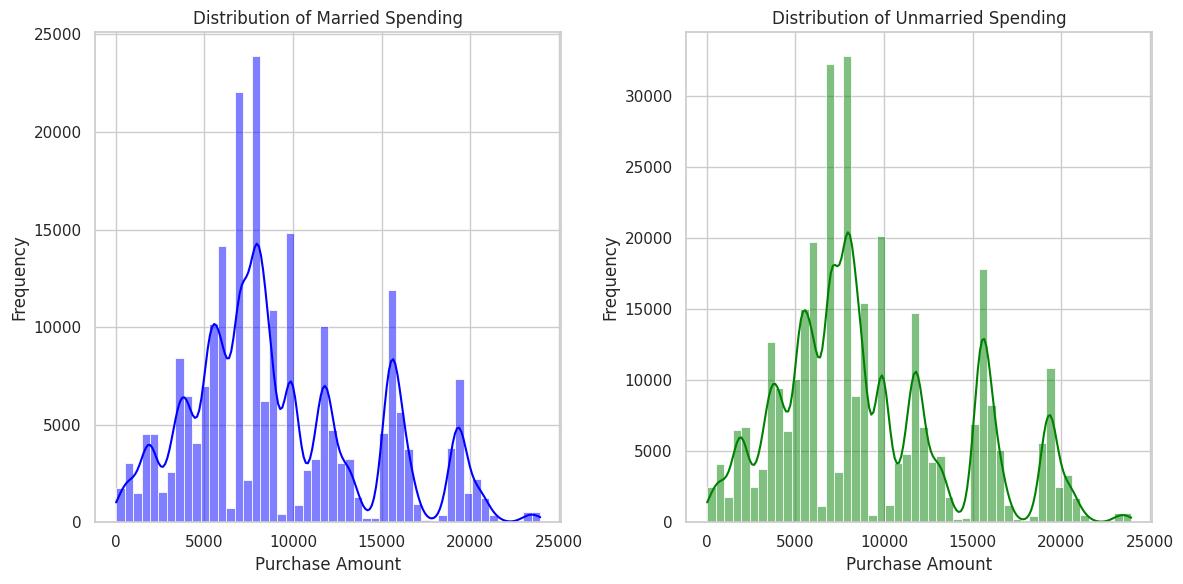


The confidence intervals for married and unmarried spending overlap.

Since the confidence intervals overlap, Walmart may not be able to distinctly differentiate spending patterns between married and unmarried customers.
Walmart could explore other factors to segment customers more effectively.


In [17]:
# Grouping purchase data by Marital Status (1 for Married, 0 for Unmarried)
married_purchase = walmart_data[walmart_data['Marital_Status'] == 1]['Purchase']
unmarried_purchase = walmart_data[walmart_data['Marital_Status'] == 0]['Purchase']
# Calculate the mean and standard deviation for both marital statuses
married_mean = married_purchase.mean()
unmarried_mean = unmarried_purchase.mean()
married_std = married_purchase.std()
unmarried_std = unmarried_purchase.std()
# Sample size
married_n = len(married_purchase)
unmarried_n = len(unmarried_purchase)
# 95% Confidence Interval calculation for Married and Unmarried customers
# Male Confidence Interval
married_margin_of_error = z_value * (married_std / np.sqrt(married_n))
married_ci_lower = married_mean - married_margin_of_error
married_ci_upper = married_mean + married_margin_of_error
# Female Confidence Interval
unmarried_margin_of_error = z_value * (unmarried_std / np.sqrt(unmarried_n))
unmarried_ci_lower = unmarried_mean - unmarried_margin_of_error
unmarried_ci_upper = unmarried_mean + unmarried_margin_of_error
# Print Confidence Intervals
print(f"95% Confidence Interval for Married Spending: ({married_ci_lower}, {married_ci_upper})")
print(f"95% Confidence Interval for Unmarried Spending: ({unmarried_ci_lower}, {unmarried_ci_upper})")
# Plotting Distribution (Histograms + KDE)
plt.figure(figsize=(12, 6))
# Married Distribution Plot
plt.subplot(1, 2, 1)
sns.histplot(married_purchase, kde=True, color='blue', bins=50)
plt.title("Distribution of Married Spending")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
# Unmarried Distribution Plot
plt.subplot(1, 2, 2)
sns.histplot(unmarried_purchase, kde=True, color='green', bins=50)
plt.title("Distribution of Unmarried Spending")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
# Check for overlap in confidence intervals between Married and Unmarried customers
if married_ci_upper >= unmarried_ci_lower and unmarried_ci_upper >= married_ci_lower:
  print("\nThe confidence intervals for married and unmarried spending overlap.")
else:
  print("\nThe confidence intervals for married and unmarried spending do not overlap.")
# Implication for Walmart
if married_ci_upper >= unmarried_ci_lower and unmarried_ci_upper >= married_ci_lower:
  print("\nSince the confidence intervals overlap, Walmart may not be able to distinctly differentiate spending patterns between married and unmarried customers.")
  print("Walmart could explore other factors to segment customers more effectively.")
else:
  print("\nSince the confidence intervals do not overlap, Walmart can confidently conclude that married and unmarried customers have distinct spending patterns.")
  print("Walmart could target promotions or marketing campaigns based on marital status.")